In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
import yfinance as yf

In [4]:
sp500 = yf.download(
    "^GSPC",
    start="1999-12-01",
    end="2026-08-01",
    auto_adjust=False,
    progress=False
)

sp500.columns = sp500.columns.get_level_values(0)
sp500.columns.name = None

sp500.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1999-12-01,1397.719971,1397.719971,1400.119995,1387.380005,1388.910034,884000000
1999-12-02,1409.040039,1409.040039,1409.040039,1397.719971,1397.719971,900700000
1999-12-03,1433.300049,1433.300049,1447.420044,1409.040039,1409.040039,1006400000
1999-12-06,1423.329956,1423.329956,1434.150024,1418.250000,1433.300049,916800000
1999-12-07,1409.170044,1409.170044,1426.810059,1409.170044,1423.329956,1085800000


In [5]:
vix = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=VIXCLS"
)

vix = vix.rename(columns={vix.columns[0]: "Date"})
vix["Date"] = pd.to_datetime(vix["Date"])
vix["VIXCLS"] = pd.to_numeric(vix["VIXCLS"], errors="coerce")

vix = vix[
    (vix["Date"] >= "1999-12-01") &
    (vix["Date"] < "2026-08-01")
]

vix = vix.set_index("Date")

vix.head()

,VIXCLS
Date,
1999-12-01,22.23
1999-12-02,21.77
1999-12-03,19.32
1999-12-06,20.58
1999-12-07,21.09


In [6]:
# Federal Funds Rate
fedfunds = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=FEDFUNDS"
)

fedfunds = fedfunds.rename(columns={fedfunds.columns[0]: "Date"})
fedfunds["Date"] = pd.to_datetime(fedfunds["Date"])
fedfunds = fedfunds[
    (fedfunds["Date"] >= "1999-01-01") &
    (fedfunds["Date"] < "2026-08-01")
].set_index("Date")


# Consumer Price Index
cpi = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=CPIAUCSL"
)

cpi = cpi.rename(columns={cpi.columns[0]: "Date"})
cpi["Date"] = pd.to_datetime(cpi["Date"])
cpi = cpi[
    (cpi["Date"] >= "1999-01-01") &
    (cpi["Date"] < "2026-08-01")
].set_index("Date")


# Unemployment Rate
unemployment = pd.read_csv(
    "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"
)

unemployment = unemployment.rename(columns={unemployment.columns[0]: "Date"})
unemployment["Date"] = pd.to_datetime(unemployment["Date"])
unemployment = unemployment[
    (unemployment["Date"] >= "1999-01-01") &
    (unemployment["Date"] < "2026-08-01")
].set_index("Date")


display(fedfunds.head())
display(cpi.head())
display(unemployment.head())

,FEDFUNDS
Date,
1999-01-01,4.63
1999-02-01,4.76
1999-03-01,4.81
1999-04-01,4.74
1999-05-01,4.74


,CPIAUCSL
Date,
1999-01-01,164.7
1999-02-01,164.7
1999-03-01,164.8
1999-04-01,165.9
1999-05-01,166.0


,UNRATE
Date,
1999-01-01,4.3
1999-02-01,4.4
1999-03-01,4.2
1999-04-01,4.3
1999-05-01,4.2


In [7]:
# -----------------------------
# 1. S&P 500 monthly variables
# -----------------------------

# Monthly closing price
monthly_close = sp500["Close"].resample("ME").last()

# Monthly S&P 500 return (%)
sp500_return = monthly_close.pct_change(fill_method=None) * 100

# Daily log return
daily_log_return = np.log(
    sp500["Close"] / sp500["Close"].shift(1)
)

# Monthly annualized realized volatility (%)
recent_volatility = (
    daily_log_return.resample("ME").std()
    * np.sqrt(252)
    * 100
)


# -----------------------------
# 2. VIX monthly average
# -----------------------------

monthly_vix = vix["VIXCLS"].resample("ME").mean()


# -----------------------------
# 3. Macroeconomic variables
# -----------------------------

# Federal Funds Rate
fed_rate = fedfunds["FEDFUNDS"].resample("ME").last()

# CPI
monthly_cpi = cpi["CPIAUCSL"].resample("ME").last()

# Year-over-year inflation rate (%)
inflation = (
    monthly_cpi.pct_change(
        periods=12,
        fill_method=None
    ) * 100
)

# Unemployment Rate
unemployment_rate = (
    unemployment["UNRATE"].resample("ME").last()
)


# -----------------------------
# 4. Build final monthly dataset
# -----------------------------

dataset = pd.DataFrame(index=monthly_close.index)

dataset["SP500_Return"] = sp500_return
dataset["Recent_Volatility"] = recent_volatility
dataset["VIX"] = monthly_vix
dataset["Fed_Funds_Rate"] = fed_rate
dataset["Inflation"] = inflation
dataset["Unemployment"] = unemployment_rate


# -----------------------------
# 5. Election-cycle variables
# -----------------------------

presidential_years = [
    2000, 2004, 2008, 2012,
    2016, 2020, 2024
]

midterm_years = [
    2002, 2006, 2010, 2014,
    2018, 2022, 2026
]

dataset["Presidential_Election_Year"] = (
    dataset.index.year.isin(presidential_years)
).astype(int)

dataset["Midterm_Election_Year"] = (
    dataset.index.year.isin(midterm_years)
).astype(int)


# -----------------------------
# 6. Target variable
# -----------------------------

# Next month's realized volatility
dataset["Future_Volatility"] = (
    dataset["Recent_Volatility"].shift(-1)
)


# -----------------------------
# 7. Final study period
# -----------------------------

dataset = dataset.loc[
    "2000-01-01":"2026-06-30"
].copy()


# -----------------------------
# 8. Display example rows
# -----------------------------

dataset.head()

,SP500_Return,Recent_Volatility,VIX,Fed_Funds_Rate,Inflation,Unemployment,Presidential_Election_Year,Midterm_Election_Year,Future_Volatility
Date,,,,,,,,,
2000-01-31,-5.090355,26.098500,23.202000,5.45,2.792957,4.0,1,0,20.020874
2000-02-29,-2.010808,20.020874,23.595500,5.73,3.217972,4.1,1,0,26.589359
2000-03-31,9.671983,26.589359,22.718261,5.85,3.762136,4.0,1,0,33.518325
2000-04-30,-3.079576,33.518325,27.164211,6.02,3.013864,3.8,1,0,24.848934
2000-05-31,-2.191505,24.848934,26.373182,6.27,3.132530,4.0,1,0,16.682265


In [8]:
summary = dataset.describe().loc[["mean", "min", "max", "std"]].T
summary

,mean,min,max,std
SP500_Return,0.610980,-16.942452,12.684404,4.389360
Recent_Volatility,16.316879,4.077899,94.186992,10.559269
VIX,19.827674,10.125455,62.668947,7.898475
Fed_Funds_Rate,2.038522,0.050000,6.540000,2.024728
Inflation,2.595725,-1.958761,8.979361,1.720837
Unemployment,5.618927,3.400000,14.800000,1.934748
Presidential_Election_Year,0.264151,0.000000,1.000000,0.441575
Midterm_Election_Year,0.245283,0.000000,1.000000,0.430933
Future_Volatility,16.272202,4.077899,94.186992,10.547801


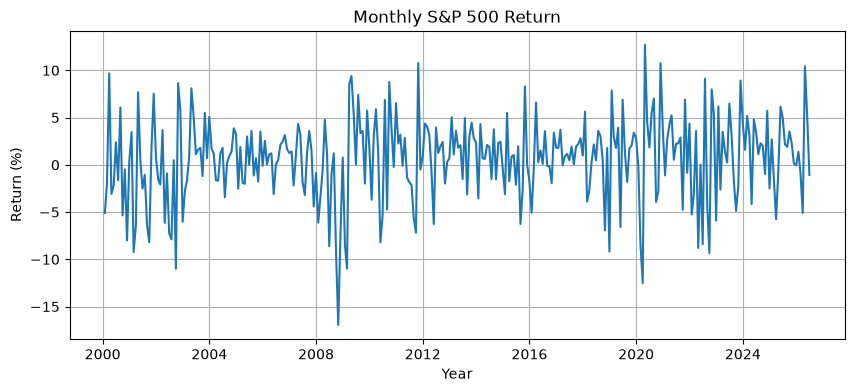

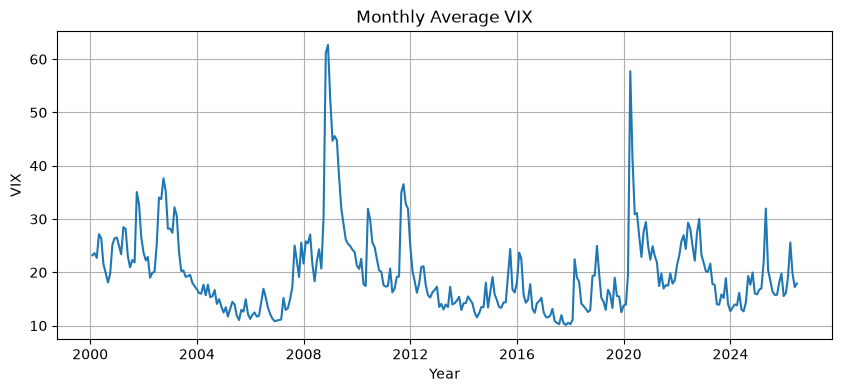

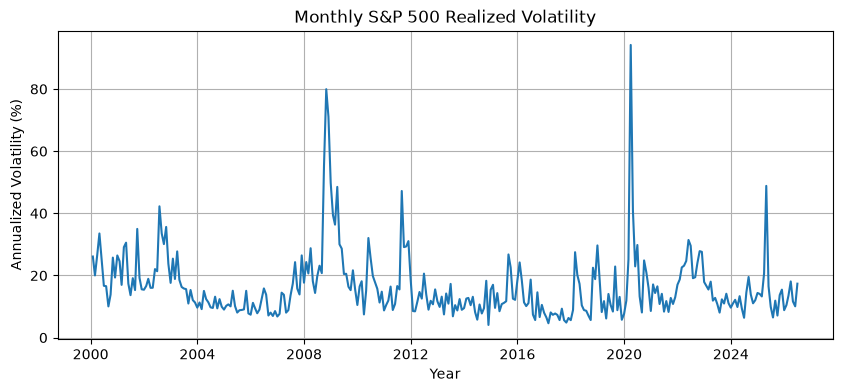

In [9]:
plt.figure(figsize=(10, 4))
plt.plot(dataset.index, dataset["SP500_Return"])
plt.title("Monthly S&P 500 Return")
plt.xlabel("Year")
plt.ylabel("Return (%)")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(dataset.index, dataset["VIX"])
plt.title("Monthly Average VIX")
plt.xlabel("Year")
plt.ylabel("VIX")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(dataset.index, dataset["Recent_Volatility"])
plt.title("Monthly S&P 500 Realized Volatility")
plt.xlabel("Year")
plt.ylabel("Annualized Volatility (%)")
plt.grid(True)
plt.show()

In [10]:
# Check for missing values
dataset.isnull().sum()

SP500_Return                  0
Recent_Volatility             0
VIX                           0
Fed_Funds_Rate                0
Inflation                     1
Unemployment                  1
Presidential_Election_Year    0
Midterm_Election_Year         0
Future_Volatility             0
dtype: int64

In [11]:
# Display rows with missing values
dataset[dataset.isnull().any(axis=1)]

,SP500_Return,Recent_Volatility,VIX,Fed_Funds_Rate,Inflation,Unemployment,Presidential_Election_Year,Midterm_Election_Year,Future_Volatility
Date,,,,,,,,,
2025-10-31,2.268687,13.696826,18.086522,4.09,NaN,NaN,0,0,15.440208


In [12]:
# Remove the row with missing values
dataset = dataset.dropna().copy()

# Check again for missing values
print(dataset.isnull().sum())

print("\nTotal samples after cleaning:", len(dataset))

SP500_Return                  0
Recent_Volatility             0
VIX                           0
Fed_Funds_Rate                0
Inflation                     0
Unemployment                  0
Presidential_Election_Year    0
Midterm_Election_Year         0
Future_Volatility             0
dtype: int64

Total samples after cleaning: 317


In [13]:
from sklearn.preprocessing import StandardScaler

# Create a copy of the cleaned dataset
scaled_dataset = dataset.copy()

# Continuous input features to scale
continuous_features = [
    "SP500_Return",
    "Recent_Volatility",
    "VIX",
    "Fed_Funds_Rate",
    "Inflation",
    "Unemployment"
]

# Apply standardization
scaler = StandardScaler()

scaled_dataset[continuous_features] = scaler.fit_transform(
    scaled_dataset[continuous_features]
)

scaled_dataset.head()

,SP500_Return,Recent_Volatility,VIX,Fed_Funds_Rate,Inflation,Unemployment,Presidential_Election_Year,Midterm_Election_Year,Future_Volatility
Date,,,,,,,,,
2000-01-31,-1.298001,0.925661,0.426550,1.690852,0.114795,-0.838087,1,0,20.020874
2000-02-29,-0.596249,0.350033,0.476373,1.829367,0.362167,-0.786319,1,0,26.589359
2000-03-31,2.065969,0.972152,0.365300,1.888731,0.678887,-0.838087,1,0,33.518325
2000-04-30,-0.839794,1.628414,0.928231,1.972829,0.243370,-0.941623,1,0,24.848934
2000-05-31,-0.637425,0.807312,0.828074,2.096504,0.312437,-0.838087,1,0,16.682265


##Phase 3

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = dataset.corr()
corr_matrix

,SP500_Return,Recent_Volatility,VIX,Fed_Funds_Rate,Inflation,Unemployment,Presidential_Election_Year,Midterm_Election_Year,Future_Volatility
SP500_Return,1.000000,-0.403351,-0.303959,-0.042061,-0.123870,0.124761,-0.055513,-0.080274,-0.436288
Recent_Volatility,-0.403351,1.000000,0.901106,-0.054268,0.029564,0.153341,0.139988,0.015156,0.645711
VIX,-0.303959,0.901106,1.000000,-0.142797,-0.017332,0.311258,0.119390,-0.001883,0.613595
Fed_Funds_Rate,-0.042061,-0.054268,-0.142797,1.000000,0.328082,-0.606978,0.056958,-0.042609,-0.028785
Inflation,-0.123870,0.029564,-0.017332,0.328082,1.000000,-0.434810,-0.037931,0.167656,0.102571
Unemployment,0.124761,0.153341,0.311258,-0.606978,-0.434810,1.000000,0.046662,-0.030622,0.089541
Presidential_Election_Year,-0.055513,0.139988,0.119390,0.056958,-0.037931,0.046662,1.000000,-0.343013,0.145955
Midterm_Election_Year,-0.080274,0.015156,-0.001883,-0.042609,0.167656,-0.030622,-0.343013,1.000000,0.026721
Future_Volatility,-0.436288,0.645711,0.613595,-0.028785,0.102571,0.089541,0.145955,0.026721,1.000000


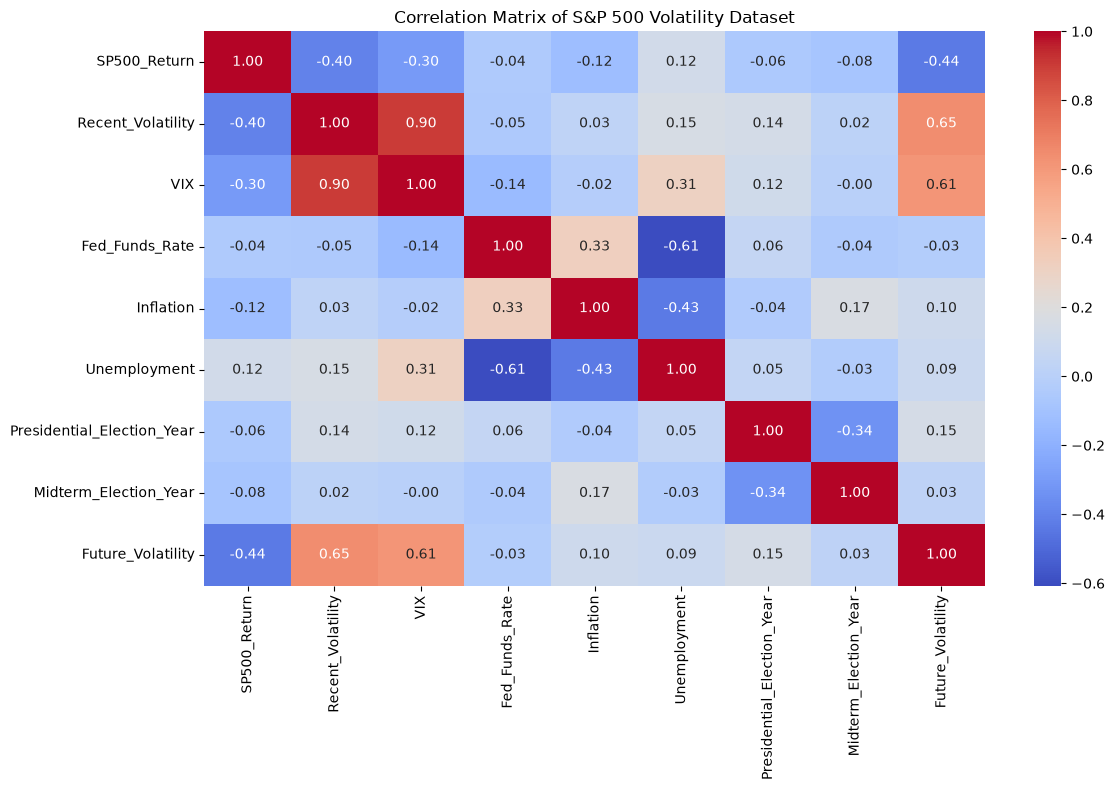

In [15]:
# Heatmap of correlation matrix
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of S&P 500 Volatility Dataset')
plt.tight_layout()
plt.show()

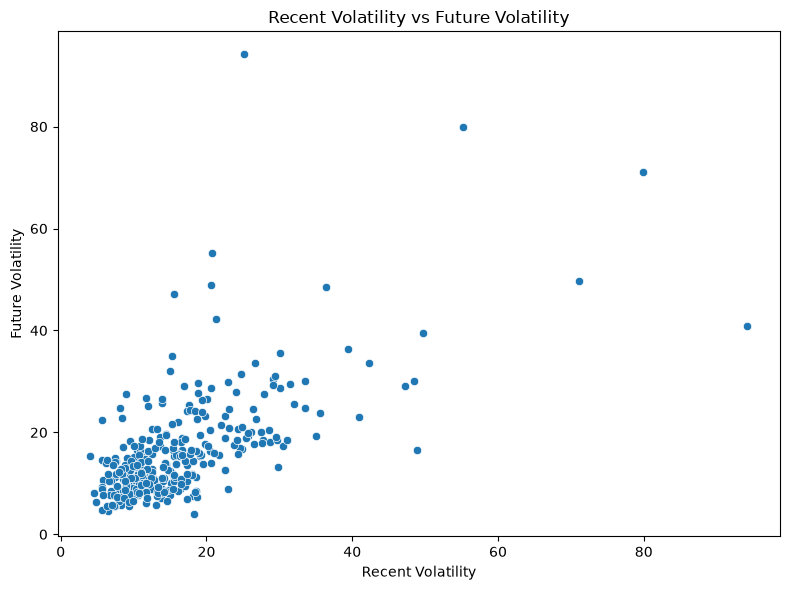

In [16]:
# Plot 1: Recent Volatility vs Future Volatility
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=dataset,
    x='Recent_Volatility',
    y='Future_Volatility'
)

plt.title('Recent Volatility vs Future Volatility')
plt.xlabel('Recent Volatility')
plt.ylabel('Future Volatility')
plt.tight_layout()
plt.show()

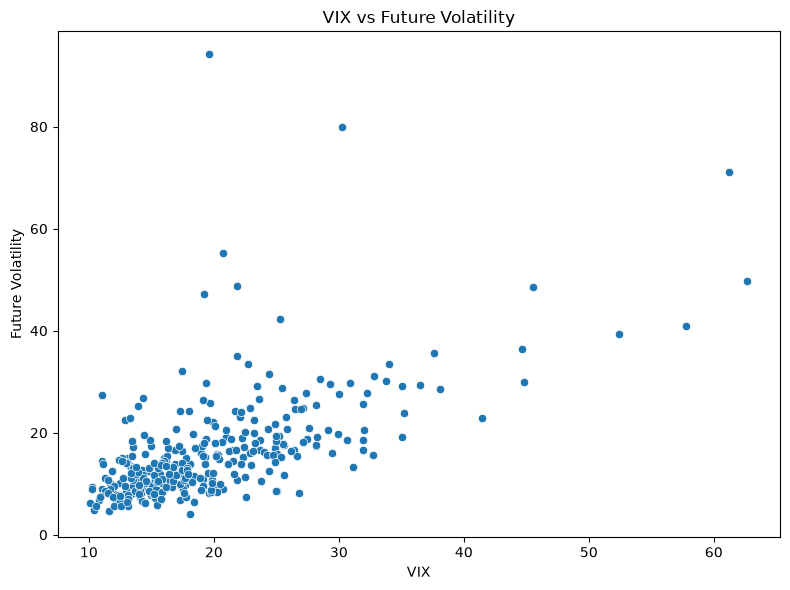

In [17]:
# Plot 2: VIX vs Future Volatility
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=dataset,
    x='VIX',
    y='Future_Volatility'
)

plt.title('VIX vs Future Volatility')
plt.xlabel('VIX')
plt.ylabel('Future Volatility')
plt.tight_layout()
plt.show()

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Input features and target
X = dataset.drop(columns=['Future_Volatility'])
y = dataset['Future_Volatility']

# Chronological 80/20 train-test split
split_index = int(len(dataset) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Prediction
y_pred_lr = lr_model.predict(X_test)

# Evaluation
lr_mse = mean_squared_error(y_test, y_pred_lr)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))
print("MSE:", lr_mse)
print("R²:", lr_r2)

Linear Regression
Training samples: 253
Testing samples: 64
MSE: 35.33875200983475
R²: 0.2830131599921547


In [19]:
from sklearn.preprocessing import PolynomialFeatures

# Create polynomial features (degree = 2)
poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

# Train Polynomial Regression model
poly_model = LinearRegression()
poly_model.fit(X_train_poly, y_train)

# Prediction
y_pred_poly = poly_model.predict(X_test_poly)

# Evaluation
poly_mse = mean_squared_error(y_test, y_pred_poly)
poly_r2 = r2_score(y_test, y_pred_poly)

print("Polynomial Regression")
print("MSE:", poly_mse)
print("R²:", poly_r2)

Polynomial Regression
MSE: 61.3106420985757
R²: -0.24392970993644658


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Scale input features
x_scaler = StandardScaler()

X_train_ann = x_scaler.fit_transform(X_train)
X_test_ann = x_scaler.transform(X_test)

# Scale target variable
y_scaler = StandardScaler()

y_train_ann = y_scaler.fit_transform(
    y_train.values.reshape(-1, 1)
).ravel()

# ANN model
ann_model = MLPRegressor(
    hidden_layer_sizes=(8,),
    activation='relu',
    solver='adam',
    alpha=0.1,
    learning_rate_init=0.001,
    max_iter=5000,
    random_state=42
)

# Train
ann_model.fit(X_train_ann, y_train_ann)

# Predict standardized target
y_pred_ann_scaled = ann_model.predict(X_test_ann)

# Convert predictions back to original volatility scale
y_pred_ann = y_scaler.inverse_transform(
    y_pred_ann_scaled.reshape(-1, 1)
).ravel()

# Evaluation
ann_mse = mean_squared_error(y_test, y_pred_ann)
ann_r2 = r2_score(y_test, y_pred_ann)

print("Artificial Neural Network")
print("MSE:", ann_mse)
print("R²:", ann_r2)

Artificial Neural Network
MSE: 35.29189250384484
R²: 0.2839638910512109


In [21]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

import pandas as pd
import matplotlib.pyplot as plt

poly_results = []

for degree in [1, 2, 3, 4]:
    
    poly_model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )
    
    # Train model
    poly_model.fit(X_train, y_train)
    
    # Predictions
    y_train_pred = poly_model.predict(X_train)
    y_test_pred = poly_model.predict(X_test)
    
    # Evaluation
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    poly_results.append([
        degree,
        train_mse,
        test_mse,
        train_r2,
        test_r2
    ])

poly_results_df = pd.DataFrame(
    poly_results,
    columns=[
        "Degree",
        "Train MSE",
        "Test MSE",
        "Train R²",
        "Test R²"
    ]
)

print(poly_results_df)

   Degree  Train MSE      Test MSE  Train R²      Test R²
0       1  65.106757     35.338752  0.485583     0.283013
1       2  44.783704     61.310642  0.646158    -0.243930
2       3  19.404465   4372.370237  0.846683   -87.710884
3       4  14.364314  52298.846554  0.886506 -1060.089671


In [ ]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

ann_results = []

learning_rates = [0.0001, 0.001, 0.01]
hidden_layers = [(8,), (16,), (16, 8)]
activations = ['relu', 'tanh']

for lr in learning_rates:
    for layers in hidden_layers:
        for activation in activations:

            model = MLPRegressor(
                hidden_layer_sizes=layers,
                activation=activation,
                solver='adam',
                alpha=0.1,
                learning_rate_init=lr,
                max_iter=5000,
                random_state=42
            )

            # Train
            model.fit(X_train_ann, y_train_ann)

            # Predictions in standardized scale
            y_train_pred_scaled = model.predict(X_train_ann)
            y_test_pred_scaled = model.predict(X_test_ann)

            # Convert predictions back to original volatility scale
            y_train_pred = y_scaler.inverse_transform(
                y_train_pred_scaled.reshape(-1, 1)
            ).ravel()

            y_test_pred = y_scaler.inverse_transform(
                y_test_pred_scaled.reshape(-1, 1)
            ).ravel()

            # Evaluation
            train_mse = mean_squared_error(y_train, y_train_pred)
            test_mse = mean_squared_error(y_test, y_test_pred)

            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)

            ann_results.append([
                lr,
                str(layers),
                activation,
                train_mse,
                test_mse,
                train_r2,
                test_r2
            ])

ann_results_df = pd.DataFrame(
    ann_results,
    columns=[
        "Learning Rate",
        "Hidden Layers",
        "Activation",
        "Train MSE",
        "Test MSE",
        "Train R²",
        "Test R²"
    ]
)

# Best test R² first
ann_results_df = ann_results_df.sort_values(
    by="Test R²",
    ascending=False
)

print(ann_results_df.round(4))

In [ ]:
ann_plot_df = ann_results_df.copy()

ann_plot_df["Configuration"] = (
    ann_plot_df["Learning Rate"].astype(str)
    + " | "
    + ann_plot_df["Hidden Layers"]
    + " | "
    + ann_plot_df["Activation"]
)

plt.figure(figsize=(12, 6))

plt.bar(
    ann_plot_df["Configuration"],
    ann_plot_df["Test R²"]
)

plt.axhline(0, linewidth=1)

plt.xlabel("ANN Configuration")
plt.ylabel("Test R²")
plt.title("Effect of ANN Hyperparameters on Test Performance")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scale features before PCA
pca_scaler = StandardScaler()

X_train_pca_scaled = pca_scaler.fit_transform(X_train)
X_test_pca_scaled = pca_scaler.transform(X_test)

# Run PCA using all components first
pca_full = PCA()
pca_full.fit(X_train_pca_scaled)

explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

pca_variance_df = pd.DataFrame({
    "Principal Component": [
        f"PC{i+1}" for i in range(len(explained_variance))
    ],
    "Explained Variance": explained_variance,
    "Cumulative Variance": cumulative_variance
})

print(pca_variance_df.round(4))

  Principal Component  Explained Variance  Cumulative Variance
0                 PC1              0.2929               0.2929
1                 PC2              0.2541               0.5470
2                 PC3              0.1631               0.7101
3                 PC4              0.0905               0.8006
4                 PC5              0.0863               0.8869
5                 PC6              0.0686               0.9555
6                 PC7              0.0356               0.9911
7                 PC8              0.0089               1.0000


In [26]:
# Apply PCA with 6 principal components
pca = PCA(n_components=6)

X_train_pca = pca.fit_transform(X_train_pca_scaled)
X_test_pca = pca.transform(X_test_pca_scaled)

print("Original training shape:", X_train.shape)
print("PCA training shape:", X_train_pca.shape)

print("Original test shape:", X_test.shape)
print("PCA test shape:", X_test_pca.shape)

print(
    "Total explained variance:",
    pca.explained_variance_ratio_.sum()
)

Original training shape: (253, 8)
PCA training shape: (253, 6)
Original test shape: (64, 8)
PCA test shape: (64, 6)
Total explained variance: 0.9555117583800538


In [27]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

pca_poly_results = []

for degree in [1, 2, 3, 4]:

    model = make_pipeline(
        PolynomialFeatures(degree=degree, include_bias=False),
        LinearRegression()
    )

    # Train using PCA data
    model.fit(X_train_pca, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_pca)
    y_test_pred = model.predict(X_test_pca)

    # Evaluation
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    pca_poly_results.append([
        degree,
        train_mse,
        test_mse,
        train_r2,
        test_r2
    ])

pca_poly_results_df = pd.DataFrame(
    pca_poly_results,
    columns=[
        "Degree",
        "Train MSE",
        "Test MSE",
        "Train R²",
        "Test R²"
    ]
)

print(pca_poly_results_df.round(4))

   Degree  Train MSE     Test MSE  Train R²    Test R²
0       1    65.2884      33.4891    0.4841     0.3205
1       2    53.0153      48.1073    0.5811     0.0240
2       3    25.3329     445.5931    0.7998    -8.0406
3       4     4.9061  170478.9712    0.9612 -3457.8425


In [28]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

ann_pca_results = []

learning_rates = [0.0001, 0.001, 0.01]
hidden_layers = [(8,), (16,), (16, 8)]
activations = ['relu', 'tanh']

for lr in learning_rates:
    for layers in hidden_layers:
        for activation in activations:

            model = MLPRegressor(
                hidden_layer_sizes=layers,
                activation=activation,
                solver='adam',
                alpha=0.1,
                learning_rate_init=lr,
                max_iter=5000,
                random_state=42
            )

            # Train ANN using PCA features
            model.fit(X_train_pca, y_train_ann)

            # Predictions in standardized target scale
            y_train_pred_scaled = model.predict(X_train_pca)
            y_test_pred_scaled = model.predict(X_test_pca)

            # Convert predictions back to original volatility scale
            y_train_pred = y_scaler.inverse_transform(
                y_train_pred_scaled.reshape(-1, 1)
            ).ravel()

            y_test_pred = y_scaler.inverse_transform(
                y_test_pred_scaled.reshape(-1, 1)
            ).ravel()

            # Evaluation
            train_mse = mean_squared_error(y_train, y_train_pred)
            test_mse = mean_squared_error(y_test, y_test_pred)

            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)

            ann_pca_results.append([
                lr,
                str(layers),
                activation,
                train_mse,
                test_mse,
                train_r2,
                test_r2
            ])

ann_pca_results_df = pd.DataFrame(
    ann_pca_results,
    columns=[
        "Learning Rate",
        "Hidden Layers",
        "Activation",
        "Train MSE",
        "Test MSE",
        "Train R²",
        "Test R²"
    ]
)

ann_pca_results_df = ann_pca_results_df.sort_values(
    by="Test R²",
    ascending=False
)

print(ann_pca_results_df.round(4))

    Learning Rate Hidden Layers Activation  Train MSE  Test MSE  Train R²  \
11         0.0010       (16, 8)       tanh    54.7352   32.9664    0.5675   
1          0.0001          (8,)       tanh    80.0174   35.5295    0.3678   
5          0.0001       (16, 8)       tanh    67.3897   35.7585    0.4675   
7          0.0010          (8,)       tanh    61.6241   38.1380    0.5131   
0          0.0001          (8,)       relu    70.1806   40.2401    0.4455   
3          0.0001         (16,)       tanh    74.5152   42.3579    0.4112   
13         0.0100          (8,)       tanh    40.4120   42.9969    0.6807   
4          0.0001       (16, 8)       relu    65.9648   43.9208    0.4788   
2          0.0001         (16,)       relu    63.0123   48.8603    0.5021   
6          0.0010          (8,)       relu    58.5429   48.9412    0.5374   
12         0.0100          (8,)       relu    51.6933   61.5271    0.5916   
8          0.0010         (16,)       relu    50.7259   69.8430    0.5992   

In [29]:
# Best Linear Regression results (degree = 1)
linear_before = poly_results_df[
    poly_results_df["Degree"] == 1
].iloc[0]

linear_after = pca_poly_results_df[
    pca_poly_results_df["Degree"] == 1
].iloc[0]


# Best NONLINEAR Polynomial Regression results (degree >= 2)
poly_before = poly_results_df[
    poly_results_df["Degree"] >= 2
].sort_values(
    by="Test R²",
    ascending=False
).iloc[0]

poly_after = pca_poly_results_df[
    pca_poly_results_df["Degree"] >= 2
].sort_values(
    by="Test R²",
    ascending=False
).iloc[0]


# Best ANN results
ann_before = ann_results_df.sort_values(
    by="Test R²",
    ascending=False
).iloc[0]

ann_after = ann_pca_results_df.sort_values(
    by="Test R²",
    ascending=False
).iloc[0]


# Create Before vs After PCA comparison table
pca_comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "ANN"
    ],

    "Before PCA Test MSE": [
        linear_before["Test MSE"],
        poly_before["Test MSE"],
        ann_before["Test MSE"]
    ],

    "After PCA Test MSE": [
        linear_after["Test MSE"],
        poly_after["Test MSE"],
        ann_after["Test MSE"]
    ],

    "Before PCA Test R²": [
        linear_before["Test R²"],
        poly_before["Test R²"],
        ann_before["Test R²"]
    ],

    "After PCA Test R²": [
        linear_after["Test R²"],
        poly_after["Test R²"],
        ann_after["Test R²"]
    ]
})

print(pca_comparison_df.round(4))

                   Model  Before PCA Test MSE  After PCA Test MSE  \
0      Linear Regression              35.3388             33.4891   
1  Polynomial Regression              61.3106             48.1073   
2                    ANN              35.2919             32.9664   

   Before PCA Test R²  After PCA Test R²  
0              0.2830             0.3205  
1             -0.2439             0.0240  
2              0.2840             0.3311  


In [32]:
import statsmodels.api as sm
import pandas as pd

# Use the original training features
X_pvalue = X_train.copy()

# Add intercept
X_pvalue_const = sm.add_constant(X_pvalue)

# Fit multiple linear regression
pvalue_model = sm.OLS(y_train, X_pvalue_const).fit()

# Display p-values
pvalues = pvalue_model.pvalues.drop("const")

pvalue_df = pd.DataFrame({
    "Feature": pvalues.index,
    "P-value": pvalues.values
})

pvalue_df = pvalue_df.sort_values(
    by="P-value"
).reset_index(drop=True)

print(pvalue_df)

                      Feature   P-value
0                SP500_Return  0.000103
1           Recent_Volatility  0.007105
2                         VIX  0.044394
3                   Inflation  0.117995
4  Presidential_Election_Year  0.274545
5              Fed_Funds_Rate  0.851889
6       Midterm_Election_Year  0.862143
7                Unemployment  0.863024


In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Scale the 3 selected features
selected_scaler = StandardScaler()

X_train_selected_scaled = selected_scaler.fit_transform(X_train_selected)
X_test_selected_scaled = selected_scaler.transform(X_test_selected)

# Use the same standardized target from before
ann_selected_results = []

learning_rates = [0.0001, 0.001, 0.01]
hidden_layers = [(8,), (16,), (16, 8)]
activations = ["relu", "tanh"]

for lr in learning_rates:
    for layers in hidden_layers:
        for activation in activations:

            model = MLPRegressor(
                hidden_layer_sizes=layers,
                activation=activation,
                solver="adam",
                alpha=0.1,
                learning_rate_init=lr,
                max_iter=5000,
                random_state=42
            )

            # Train
            model.fit(X_train_selected_scaled, y_train_ann)

            # Predict standardized y
            y_train_pred_scaled = model.predict(X_train_selected_scaled)
            y_test_pred_scaled = model.predict(X_test_selected_scaled)

            # Convert back to original volatility scale
            y_train_pred = y_scaler.inverse_transform(
                y_train_pred_scaled.reshape(-1, 1)
            ).ravel()

            y_test_pred = y_scaler.inverse_transform(
                y_test_pred_scaled.reshape(-1, 1)
            ).ravel()

            # Evaluation
            train_mse = mean_squared_error(y_train, y_train_pred)
            test_mse = mean_squared_error(y_test, y_test_pred)

            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)

            ann_selected_results.append([
                lr,
                str(layers),
                activation,
                train_mse,
                test_mse,
                train_r2,
                test_r2
            ])

ann_selected_results_df = pd.DataFrame(
    ann_selected_results,
    columns=[
        "Learning Rate",
        "Hidden Layers",
        "Activation",
        "Train MSE",
        "Test MSE",
        "Train R²",
        "Test R²"
    ]
)

ann_selected_results_df = ann_selected_results_df.sort_values(
    by="Test R²",
    ascending=False
)

print(ann_selected_results_df.round(4))

    Learning Rate Hidden Layers Activation  Train MSE  Test MSE  Train R²  \
17         0.0100       (16, 8)       tanh    50.6525   29.6916    0.5998   
3          0.0001         (16,)       tanh    71.3688   29.7335    0.4361   
8          0.0010         (16,)       relu    63.3919   30.4090    0.4991   
15         0.0100         (16,)       tanh    60.4990   30.6502    0.5220   
9          0.0010         (16,)       tanh    64.8497   30.6808    0.4876   
2          0.0001         (16,)       relu    71.3599   30.7732    0.4362   
11         0.0010       (16, 8)       tanh    65.1391   30.9971    0.4853   
7          0.0010          (8,)       tanh    67.6195   31.1816    0.4657   
4          0.0001       (16, 8)       relu    66.8573   31.2043    0.4718   
10         0.0010       (16, 8)       relu    61.0436   31.5495    0.5177   
6          0.0010          (8,)       relu    61.5564   32.1803    0.5136   
14         0.0100         (16,)       relu    51.9560   32.6326    0.5895   

In [41]:
# Final best ANN after p-value feature selection
final_ann = MLPRegressor(
    hidden_layer_sizes=(16, 8),
    activation="tanh",
    solver="adam",
    alpha=0.1,
    learning_rate_init=0.01,
    max_iter=5000,
    random_state=42
)

final_ann.fit(X_train_selected_scaled, y_train_ann)
# Final selected features
selected_features = [
    "SP500_Return",
    "Recent_Volatility",
    "VIX"
]

# Get the latest observation from the full dataset
latest_features = X[selected_features].iloc[[-1]]

print("Latest observation:")
print(latest_features)

# Show the month/date if X uses a datetime index
print("\nLatest data month:")
print(latest_features.index[0])

# Scale with the same scaler used for the final ANN
latest_features_scaled = selected_scaler.transform(latest_features)

# Predict next month's volatility
next_month_pred_scaled = final_ann.predict(latest_features_scaled)

# Convert back to original volatility scale
next_month_volatility = y_scaler.inverse_transform(
    next_month_pred_scaled.reshape(-1, 1)
).ravel()[0]

print("\nPredicted Next-Month S&P 500 Volatility:")
print(round(next_month_volatility, 2))

Latest observation:
            SP500_Return  Recent_Volatility        VIX
Date                                                  
2026-06-30     -1.064638          17.358752  17.906818

Latest data month:
2026-06-30 00:00:00

Predicted Next-Month S&P 500 Volatility:
15.69
